# Polytech Paris Saclay | 3ème année


# TP1 Algo-Num-1: la méthode de Newton

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Exercice 1: étude de la fonction $f_1(x) = e^x + x$

### 1.1 coder la fonction `f1(x)` qui prend un réel x en entrée

In [2]:
def f1(x):
    return np.exp(x) + x

### 1.2 dessiner le graphe de $f_1$ sur l'intervalle $[-20, 5]$

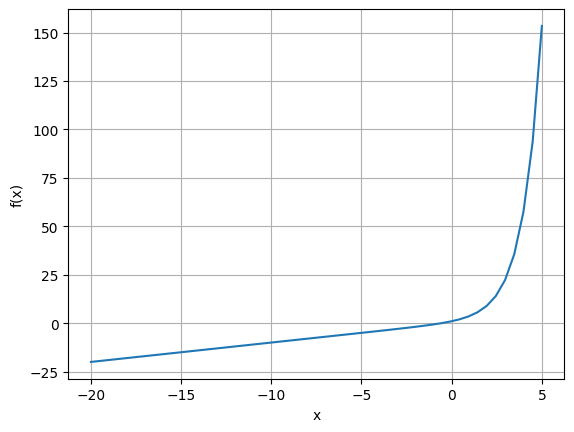

In [3]:
x = np.linspace(-20, 5)
y = f1(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

changer l'échelle de l'axe de abcisses pour localiser visuellement précisément le zéro de f1.

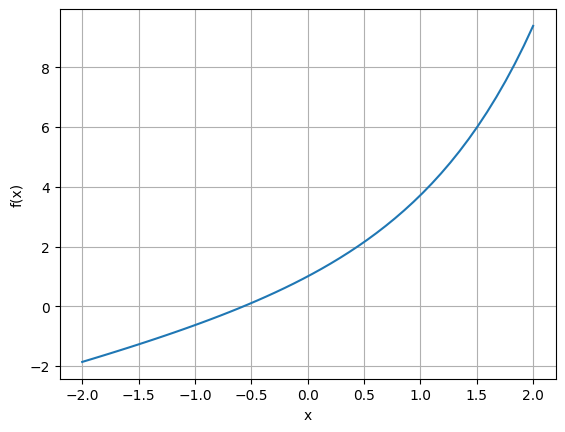

In [4]:
x = np.linspace(-2, 2)
y = f1(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

### 1.3 coder `f1prime(x)`, dérivée de $f_1$, qui prend x réel en entrée.

In [5]:
def f1prime(x):
    return np.exp(x) + 1

### 1.4 coder la fonction `NewtonA(x0,f,fprime,n)` qui prend en entrée: x0 la semence, f la fonction étudiée, fprime sa dérivée et n un nombre d'itérations.

In [6]:
def NewtonA(x0, f, fprime, n):
    x = x0
    for _ in range(n):
        x = x - f(x)/fprime(x)
    return x

### 1.5 tester `NewtonA` sur `f1` et `f1prime` pour différentes valeurs x0 de semence en entrée

Choisir une valeur de n qui vous parait pertinente et tester une dizaine de valeurs de x0.

In [7]:
# Itérations
n = 100

In [8]:
print(-5, " : ", NewtonA(-5, f1, f1prime, n))

-5  :  -0.5671432904097838


In [9]:
print(-2, " : ", NewtonA(-2, f1, f1prime, n))

-2  :  -0.5671432904097838


In [10]:
print(2, " : ", NewtonA(2, f1, f1prime, n))

2  :  -0.5671432904097838


In [11]:
print(10, " : ", NewtonA(10, f1, f1prime, n))

10  :  -0.5671432904097838


In [12]:
print(-20, " : ", NewtonA(-20, f1, f1prime, n))

-20  :  -0.5671432904097838


In [13]:
print(100, " : ", NewtonA(100, f1, f1prime, n))

100  :  -0.21089547012886678


In [14]:
print(200, " : ", NewtonA(200, f1, f1prime, n))

200  :  100.0


Pouvez-vous donner une interprétation quant à la convergence et au choix de x0 ? Il peut être intéressant d'afficher la valeur courante de la solution à chaque itération.

_Solution_

Si on choisit une valeur déjà proche de la valeur de zéro de f1, la méthode de Newton converge rapidement vers la solution. Cependant, l'algorithme de Newton peut convergé vers une autre valeur si la valeur de $x_0$ est trop éloignée de $f(x) = 0$

Sinon, prenez une meilleure valeur de n et recommencez les tests. Conclusion ?

_Solution_

J'ai modifié la valeur du nombre d'itérations, de $100$ à $1000$, afin de permettre à l'algorithme de converger vers la solution, même pour des valeurs de x0 plus éloignées du zéro de f1.

### 1.6 coder la fonction `NewtonB(x0,f,fprime,tol)` qui prend en entrée: x0, la semence, f la fonction étudiée, fprime sa dérivée et tol la tolérance évaluée sur $|f(x_n)|\leq tol$,  et qui renvoie la valeur approchée de la solution ainsi que le nombre d'itérations faites. 

In [15]:
def NewtonB(x0, f, fprime, tol):
    it = 0
    x = x0
    while abs(f(x)) > tol:
        x = x - f(x)/fprime(x)
        it += 1
    return ( x, it )

### Utilisez NewtonB sur `f1`
Faites plusieurs tests en ne faisant varier qu'un seul paramètre d'entrée à la fois: x0 ou tol

In [16]:
tol = 10e-2
x0 = 10

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonB(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  10 tol :  0.1
valeur : -0.5418139234189425 itérations :  11


In [17]:
tol = 10e-5
x0 = 90

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonB(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  90 tol :  0.0001
valeur : -0.5671432879436327 itérations :  93


In [18]:
tol = 10e-5
x0 = -200

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonB(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  -200 tol :  0.0001
valeur : -0.5671431650348622 itérations :  4


In [19]:
tol = 10e-8
x0 = 10

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonB(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  10 tol :  1e-07
valeur : -0.567143287933324 itérations :  13


In [20]:
tol = 10e-22
x0 = 200

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonB(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  200 tol :  1e-21
valeur : -0.5671432904097838 itérations :  205


### 1.7 coder la fonction `NewtonC(x0,f,fprime,tol)` qui prend en entrée: x0, la semence, f la fonction étudiée, fprime sa dérivée et tol la tolérance évaluée sur $|x_{n+1}-x_n|\leq tol$ ,  et qui renvoie la valeur approchée de la solution ainsi que le nombre d'itérations faites. 


In [21]:
def NewtonC(x0, f, fprime, tol):
    it = 0
    xn = x0 # x_n
    xnp = NewtonA(x0, f, fprime, 1) # x_n+1
    while abs(xnp - xn) > tol:
        xn = xnp
        xnp = xn - f(xn)/fprime(xn)
        it += 1
    return ( xnp, it )

### Utilisez le sur `f1`

In [22]:
tol = 10e-2
x0 = 10

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonC(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  10 tol :  0.1
valeur : -0.5670263052290061 itérations :  11


In [23]:
tol = 10e-5
x0 = 90

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonC(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  90 tol :  0.0001
valeur : -0.567143290409784 itérations :  93


In [24]:
tol = 10e-5
x0 = -200

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonC(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  -200 tol :  0.0001
valeur : -0.5671432904097811 itérations :  4


In [25]:
tol = 10e-64
x0 = 60

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonC(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  60 tol :  1e-63
valeur : -0.5671432904097838 itérations :  65


### 1.8 La vitesse de convergence est indiquée par le rapport $\dfrac{x_{n+1}-x_n}{x_n-x_{n-1}}$, ce rapport tend vers 0 dans le cas d'un algorithme de Newton convergeant. 

### Coder la fonction `NewtonD(x0,f,fprime,tol)` qui prend en entrée: x0 la semence, f la fonction étudiée, fprime sa dérivée et tol la tolérance évaluée sur $\Big|\dfrac{x_{n+1}-x_n}{x_n-x_{n-1}}\Big|\leq tol$ ,  et qui renvoie la valeur approchée de la solution ainsi que le nombre d'itérations faites. 


In [26]:
def NewtonD(x0, f, fprime, tol):
    it = 0

    xn_m = x0 # x_n-1
    xn = NewtonA(xn_m, f, fprime, 1) # x_n
    xnp = NewtonA(xn, f, fprime, 1) # x_n+1

    while abs((xnp - xn)/(xn - xn_m)) > tol:
        xn_m = xn
        xn = xnp
        xnp = xn - f(xn)/fprime(xn)
        it += 1
    return ( xnp, it )

### Utilisez le sur `f1`

In [27]:
tol = 10e-64
x0 = 60

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonD(x0, f1, f1prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  60 tol :  1e-63
valeur : -0.5671432904097838 itérations :  64


## Exercice 2: Autres fonctions scalaires

### 2.1 Polynôme de degré 3 
$P(x)=x^3 - 4x + 1$. 

Appliquer l'algorithme de Newton pour déterminer la ou les racines de $P$, on commencera par tracer la courbe de $P$ pour évaluer le nombre potentiel de racines et les valeurs de semences appropriées.

In [28]:
def f2(x):
    return x**3 - 4*x + 1

In [29]:
def f2prime(x):
    return 3*x**2 - 4

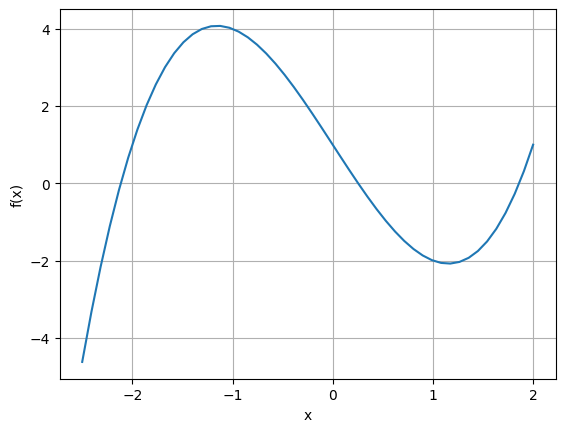

In [30]:
x = np.linspace(-2.5, 2)
y = f2(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

_Solution_

Nous pouvons constater que notre fonction f2 a 3 racines potentielles 

In [31]:
tol = 10e-2
x0 = -3

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonD(x0, f2, f2prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  -3 tol :  0.1
valeur : -2.114908266449071 itérations :  2


In [32]:
tol = 10e-2
x0 = 0

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonD(x0, f2, f2prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  0 tol :  0.1
valeur : 0.2540983606557377 itérations :  0


In [33]:
tol = 10e-2
x0 = 1

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonD(x0, f2, f2prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  1 tol :  0.1
valeur : 1.8608706827071453 itérations :  4


## 2.2 Fonction logarithme népérien. 
L'objectif de cette question est de constater la pertinence du choix de la semence. Appliquer l'algorithme de NewtonC sur la fonction `np.log()`, et en déduire l'intervalle dans lequel prendre x0 pour que l'algorithme converge. 

In [71]:
def f3(x):
    return np.where(x > 0, np.log(x), np.nan)

In [ ]:
def f3prime(x):
    return np.where(x > 0, 1/x, np.nan)

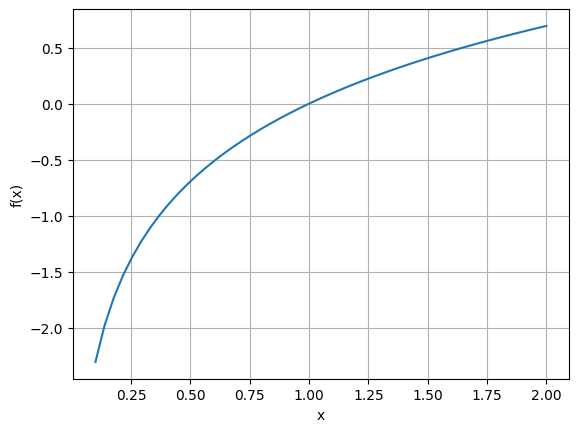

In [77]:
x = np.linspace(0.1, 2)
y = f3(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

In [100]:
tol = 10e-3
x0 = 2

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonC(x0, f3, f3prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  2 tol :  0.01
valeur : 0.9999925084748383 itérations :  3


In [104]:
tol = 10e-10
x0 = 2.5

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonC(x0, f3, f3prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  2.5 tol :  1e-09
valeur : 1.0 itérations :  6


In [105]:
tol = 10e-20
x0 = 2.5

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonC(x0, f3, f3prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  2.5 tol :  1e-19
valeur : 1.0 itérations :  7


In [113]:
tol = 10e-64
x0 = 2.5

print("x0 : ",x0, "tol : ", tol)

x, it = NewtonC(x0, f3, f3prime, tol)
print("valeur :", x, "itérations : ", it)

x0 :  2.5 tol :  1e-63
valeur : 1.0 itérations :  7


## 2.3 formule de Héron pour extraire une racine carrée du nombre $a>0$
Vérifier (sur le papier) que le point fixe de la fonction $h(a,x)=\dfrac{1}{2}\left(x+\dfrac{a}{x}\right)$ est bien $x=\sqrt{a}$. Indication: résoudre $h(a,x) = x$ ou encore $h(a,x) - x = 0$. 



## En déduire par l'application de l'algorithme de Newton une valeur approchée à $10^{-8}$ de $\sqrt{a}$ pour $a=2$

## Exercice 3: Newton sur un système 2 $\times$ 2

On veut résoudre le système suivant:
$$
f(x,y)=\left\{
    \begin{array}{c}
       2\sin(x)+2\cos(y)-5x = 0 \\
       2\cos(x)+ 2\sin(y)-5y=0
    \end{array}
\right.
$$ 

* Ecrire la fonction $f$ de deux variables
* Ecrire la matrice Jacobienne de $f$, notée $J$
* On pourra utiliser la fonction numpy.linalg.inv() pour inverser la jacobienne.
* Mettre en oeuvre la méthode de Newton pour un système pour résoudre ce système.

In [114]:
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
def f(x, y):
    # return 2 * np.sin(x) + 2. * np.cos(y) - 5 * x
    return 2 * np.cos(x) + 2. * np.sin(y) - 5 * y

## Exercice 4: Newton dans un système 4 $\times$ 4


On considère une matrice A  2 $\times$ 2, dont les 4 coordonnées sont les inconnues.
* écrire le système $A^2 =I$, 
* écrire la jacobienne associée.

Comme c'est une matrice  4 $\times$ 4, pour cette première approche, on utilise `np.linalg.inv` pour calculer son inverse et résoudre le problème.